# 🛌 Sleep-Stage Classification — Exploratory Data Analysis

**Goal.** Each row is one 30-second *epoch* of sleep described by 21 physiological
signals (brain waves, muscle tone, eye movement, heart, breathing). For every epoch
in the unlabeled test set (`final-check.csv`) we must predict its **sleep stage**
(`sleep_stage` ∈ {0, 1, 2, 3}).

This notebook is a **full EDA done before any modeling**. EDA is not decoration — it is
how we decide *what model to build and how to prepare the data*. For each step below I
state **what** I look at and **why it matters for the final model**.

**EDA roadmap**
1. Load data & first look (shapes, types)
2. Data dictionary — what the 21 signals mean
3. Target analysis — how many stages, is it balanced?
4. Missing values — where, how much, is it the same in test?
5. Univariate distributions — scale & shape of every feature
6. Outliers — are extreme values real or errors?
7. **Train vs Test distribution** — will a model trained here generalize there?
8. Correlation / redundancy between features
9. Feature → target signal — which signals actually separate the stages?
10. Per-stage physiological profiles — what does each stage *look* like?
11. PCA — are the classes separable in 2D?
12. Key takeaways & modeling plan

## 1. Setup & data load

**Why:** before anything else we load both files and fix a clean list of feature
columns vs. the target. We load the test set (`final-check.csv`) *now* so that every
distribution check can be done **train vs test side-by-side** — the single most
important thing in a competition is that the data we learn from looks like the data we
are scored on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

train = pd.read_csv("train.csv")
test  = pd.read_csv("final-check.csv")     # unlabeled — this is what we must predict

TARGET   = "sleep_stage"
ID       = "id"
FEATURES = [c for c in train.columns if c not in (ID, TARGET)]

print(f"train: {train.shape[0]} rows  x  {train.shape[1]} cols")
print(f"test : {test.shape[0]} rows  x  {test.shape[1]} cols")
print(f"\n{len(FEATURES)} feature columns")

train: 9000 rows  x  23 cols
test : 5000 rows  x  22 cols

21 feature columns


## 2. First look & structure

**Why:** `head()` confirms the columns line up between train and test, and `info()` /
`dtypes` tell us the *machine* types. Here every feature is already **numeric float** —
there are **no text/categorical columns to encode**, which removes a whole class of
preprocessing work. We also confirm the test set has the same columns *minus* the
target.

In [2]:
train.head()

,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,emg_chin_tone,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,2.79720,-1.76807,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,0.66264,-0.35469,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,-2.08711,1.49050,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,0.98192,1.12176,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,-2.74524,-0.31044,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       9000 non-null   int64  
 1   eeg_delta_power          9000 non-null   float64
 2   eeg_theta_power          9000 non-null   float64
 3   eeg_alpha_power          9000 non-null   float64
 4   eeg_sigma_power          9000 non-null   float64
 5   eeg_beta_power           9000 non-null   float64
 6   eeg_gamma_power          9000 non-null   float64
 7   eeg_slow_osc_power       9000 non-null   float64
 8   eeg_spectral_entropy     9000 non-null   float64
 9   eeg_spindle_density      9000 non-null   float64
 10  eeg_kcomplex_rate        9000 non-null   float64
 11  emg_chin_tone            9000 non-null   float64
 12  emg_tone_variance        9000 non-null   float64
 13  eog_movement_density     9000 non-null   float64
 14  eog_amplitude           

In [4]:
# Columns present in train but not in test  -> should be exactly the target
print("Only in train:", set(train.columns) - set(test.columns))
print("Only in test :", set(test.columns) - set(train.columns))
print("\nDtype counts:\n", train.dtypes.value_counts())

Only in train: {'sleep_stage'}
Only in test : set()

Dtype counts:
 float64    21
int64       2
Name: count, dtype: int64


## 3. Data dictionary — what the signals actually mean

**Why:** these aren't anonymous `feature_1..21`; they are named **polysomnography**
measurements. Knowing the physiology lets us sanity-check the data and later *interpret*
the model instead of trusting it blindly. The 21 signals fall into four sensor families:

| Family | Columns | What it measures |
|---|---|---|
| **EEG** (brain waves) | `eeg_delta/theta/alpha/sigma/beta/gamma_power`, `eeg_slow_osc_power`, `eeg_spectral_entropy`, `eeg_spindle_density`, `eeg_kcomplex_rate` | Power in each frequency band + sleep-specific graphoelements. Delta/slow-osc ⇒ deep sleep; sigma/spindles & K-complexes ⇒ light sleep (N2); alpha ⇒ relaxed wake; high entropy ⇒ desynchronized (REM/wake). |
| **EMG** (muscle) | `emg_chin_tone`, `emg_tone_variance` | Chin muscle tone. High in wake, **lowest in REM** (muscle atonia). |
| **EOG** (eyes) | `eog_movement_density`, `eog_amplitude`, `eog_burst_index` | Eye-movement activity. Bursts of rapid movement ⇒ REM. |
| **Autonomic** | `heart_rate_mean`, `heart_rate_variability`, `respiration_rate`, `respiration_variability`, `spo2_mean`, `body_movement_index` | Heart, breathing, blood-oxygen and gross body movement. |

So this is a classic sleep-staging problem and we should expect the stages to be
distinguishable by *combinations* of these signals.

In [5]:
# Group the features by sensor family for later use
GROUPS = {
    "EEG": [c for c in FEATURES if c.startswith("eeg_")],
    "EMG": [c for c in FEATURES if c.startswith("emg_")],
    "EOG": [c for c in FEATURES if c.startswith("eog_")],
    "Autonomic": [c for c in FEATURES if c.split("_")[0] in
                  ("heart","respiration","spo2","body")],
}
for g, cols in GROUPS.items():
    print(f"{g:10s} ({len(cols)}): {cols}")

EEG        (10): ['eeg_delta_power', 'eeg_theta_power', 'eeg_alpha_power', 'eeg_sigma_power', 'eeg_beta_power', 'eeg_gamma_power', 'eeg_slow_osc_power', 'eeg_spectral_entropy', 'eeg_spindle_density', 'eeg_kcomplex_rate']
EMG        (2): ['emg_chin_tone', 'emg_tone_variance']
EOG        (3): ['eog_movement_density', 'eog_amplitude', 'eog_burst_index']
Autonomic  (6): ['heart_rate_mean', 'heart_rate_variability', 'respiration_rate', 'respiration_variability', 'spo2_mean', 'body_movement_index']


### 3a. Summary statistics — note the scaling

**Why:** `describe()` reveals that every feature is roughly **centered at 0** (means
≈ 0) — the data has already been **standardized**. But the standard deviations differ
(≈ 1.0 to 5.0), so it is *not* perfectly unit-variance. The practical consequence:

- **Distance / gradient based models** (KNN, SVM, logistic regression, neural nets) are
  sensitive to scale, so we should still apply a `StandardScaler` in the pipeline.
- **Tree based models** (Random Forest, XGBoost, CatBoost) are scale-invariant and can
  use the raw values directly.

In [6]:
train[FEATURES].describe().T[["mean","std","min","max"]].round(3)

,mean,std,min,max
eeg_delta_power,-0.015,2.431,-9.567,8.798
eeg_theta_power,-0.034,2.408,-8.277,9.222
eeg_alpha_power,-0.016,5.042,-20.632,18.870
eeg_sigma_power,0.012,2.207,-7.948,9.603
eeg_beta_power,-0.010,2.883,-11.460,10.027
eeg_gamma_power,-0.011,2.428,-9.638,8.296
eeg_slow_osc_power,-0.014,2.801,-14.123,10.362
eeg_spectral_entropy,0.010,2.753,-9.301,10.160
eeg_spindle_density,0.006,2.174,-8.828,8.937
eeg_kcomplex_rate,0.007,1.948,-8.090,7.064


## 4. Target analysis — `sleep_stage`

**Why:** the target's shape drives three modeling decisions: (1) how many classes →
this is **multiclass (4 stages)**; (2) **class balance** → tells us whether plain
*accuracy* is an honest metric or whether we need stratification / class weights;
(3) the right **cross-validation** scheme.

             count  proportion
sleep_stage                   
0             2001       0.222
1             2442       0.271
2             2237       0.249
3             2320       0.258

Classes: 4  |  imbalance ratio (max/min): 1.22


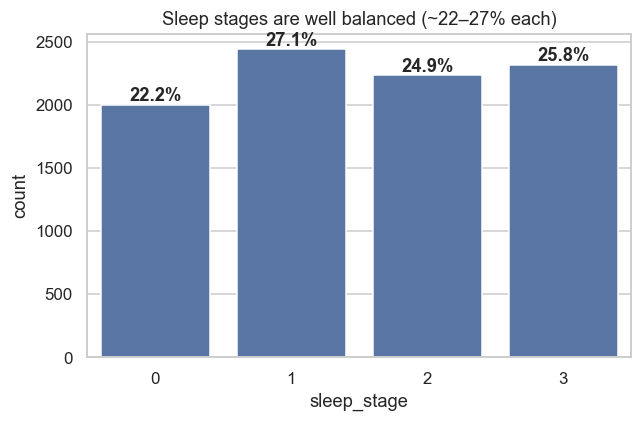

In [7]:
counts = train[TARGET].value_counts().sort_index()
props  = train[TARGET].value_counts(normalize=True).sort_index()

summary = pd.DataFrame({"count": counts, "proportion": props.round(3)})
print(summary)
print(f"\nClasses: {train[TARGET].nunique()}  |  "
      f"imbalance ratio (max/min): {counts.max()/counts.min():.2f}")

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v+30, f"{props.iloc[i]*100:.1f}%", ha="center", fontweight="bold")
ax.set(title="Sleep stages are well balanced (~22–27% each)",
       xlabel="sleep_stage", ylabel="count")
plt.tight_layout(); plt.show()

**Read:** the four stages are almost evenly represented (≈ 22–27%), imbalance ratio
≈ 1.2. That means:
- **Accuracy is a fair primary metric** (no class dominates), but we'll still watch
  **macro-F1** and a **confusion matrix** to make sure we don't sacrifice the smallest
  class.
- We will use **`StratifiedKFold`** so every fold keeps these proportions.

## 5. Missing values

**Why:** missing data forces a choice — drop the column, drop the rows, or impute.
The decision must be based on (a) *how much* is missing, (b) *whether the column is
still useful*, and critically (c) **whether the test set is missing the same thing** —
we cannot drop a column from train if we still have to score it in test.

In [8]:
miss = pd.DataFrame({
    "train_missing": train[FEATURES].isna().sum(),
    "train_pct":    (train[FEATURES].isna().mean()*100).round(1),
    "test_missing":  test[FEATURES].isna().sum(),
    "test_pct":     (test[FEATURES].isna().mean()*100).round(1),
})
miss[miss.train_missing > 0]

,train_missing,train_pct,test_missing,test_pct
eog_burst_index,4501,50.0,2477,49.5


**Read:** exactly one column, **`eog_burst_index`, is ~50% missing — in *both* train
and test**. This is the key finding of this section:

- The missingness is **consistent across train and test**, so it is a property of the
  signal (these eye-movement bursts simply aren't always detectable), not a data-loading
  bug.
- We **must not drop the column** just because half is missing — we'll check in §9
  whether it still carries signal (spoiler: it's one of the most discriminative
  features). Dropping it would throw away real information.
- Plan: **impute** (median, or model-based) **and add a binary "was-missing" flag**, so
  the model can use the *fact* that the burst index was absent as information.

In [9]:
# A clean way to confirm consistency + preview the missing-indicator idea
print("eog_burst_index missing — train: "
      f"{train['eog_burst_index'].isna().mean()*100:.1f}%   "
      f"test: {test['eog_burst_index'].isna().mean()*100:.1f}%")

# Does missingness relate to the target? (if yes, the flag is predictive)
flag = train["eog_burst_index"].isna().astype(int)
print("\nP(missing) by sleep_stage:")
print(flag.groupby(train[TARGET]).mean().round(3))

eog_burst_index missing — train: 50.0%   test: 49.5%

P(missing) by sleep_stage:
sleep_stage
0    0.486
1    0.496
2    0.504
3    0.512
Name: eog_burst_index, dtype: float64


## 6. Univariate distributions — every feature at a glance

**Why:** one histogram per feature tells us the *shape* (symmetric / skewed /
multi-modal) and confirms the scale. **Multi-modal** (multiple humps) features are
exciting for a classifier — separate humps often correspond to different sleep stages.
Heavy skew might call for a transform; clean bell shapes are model-friendly.

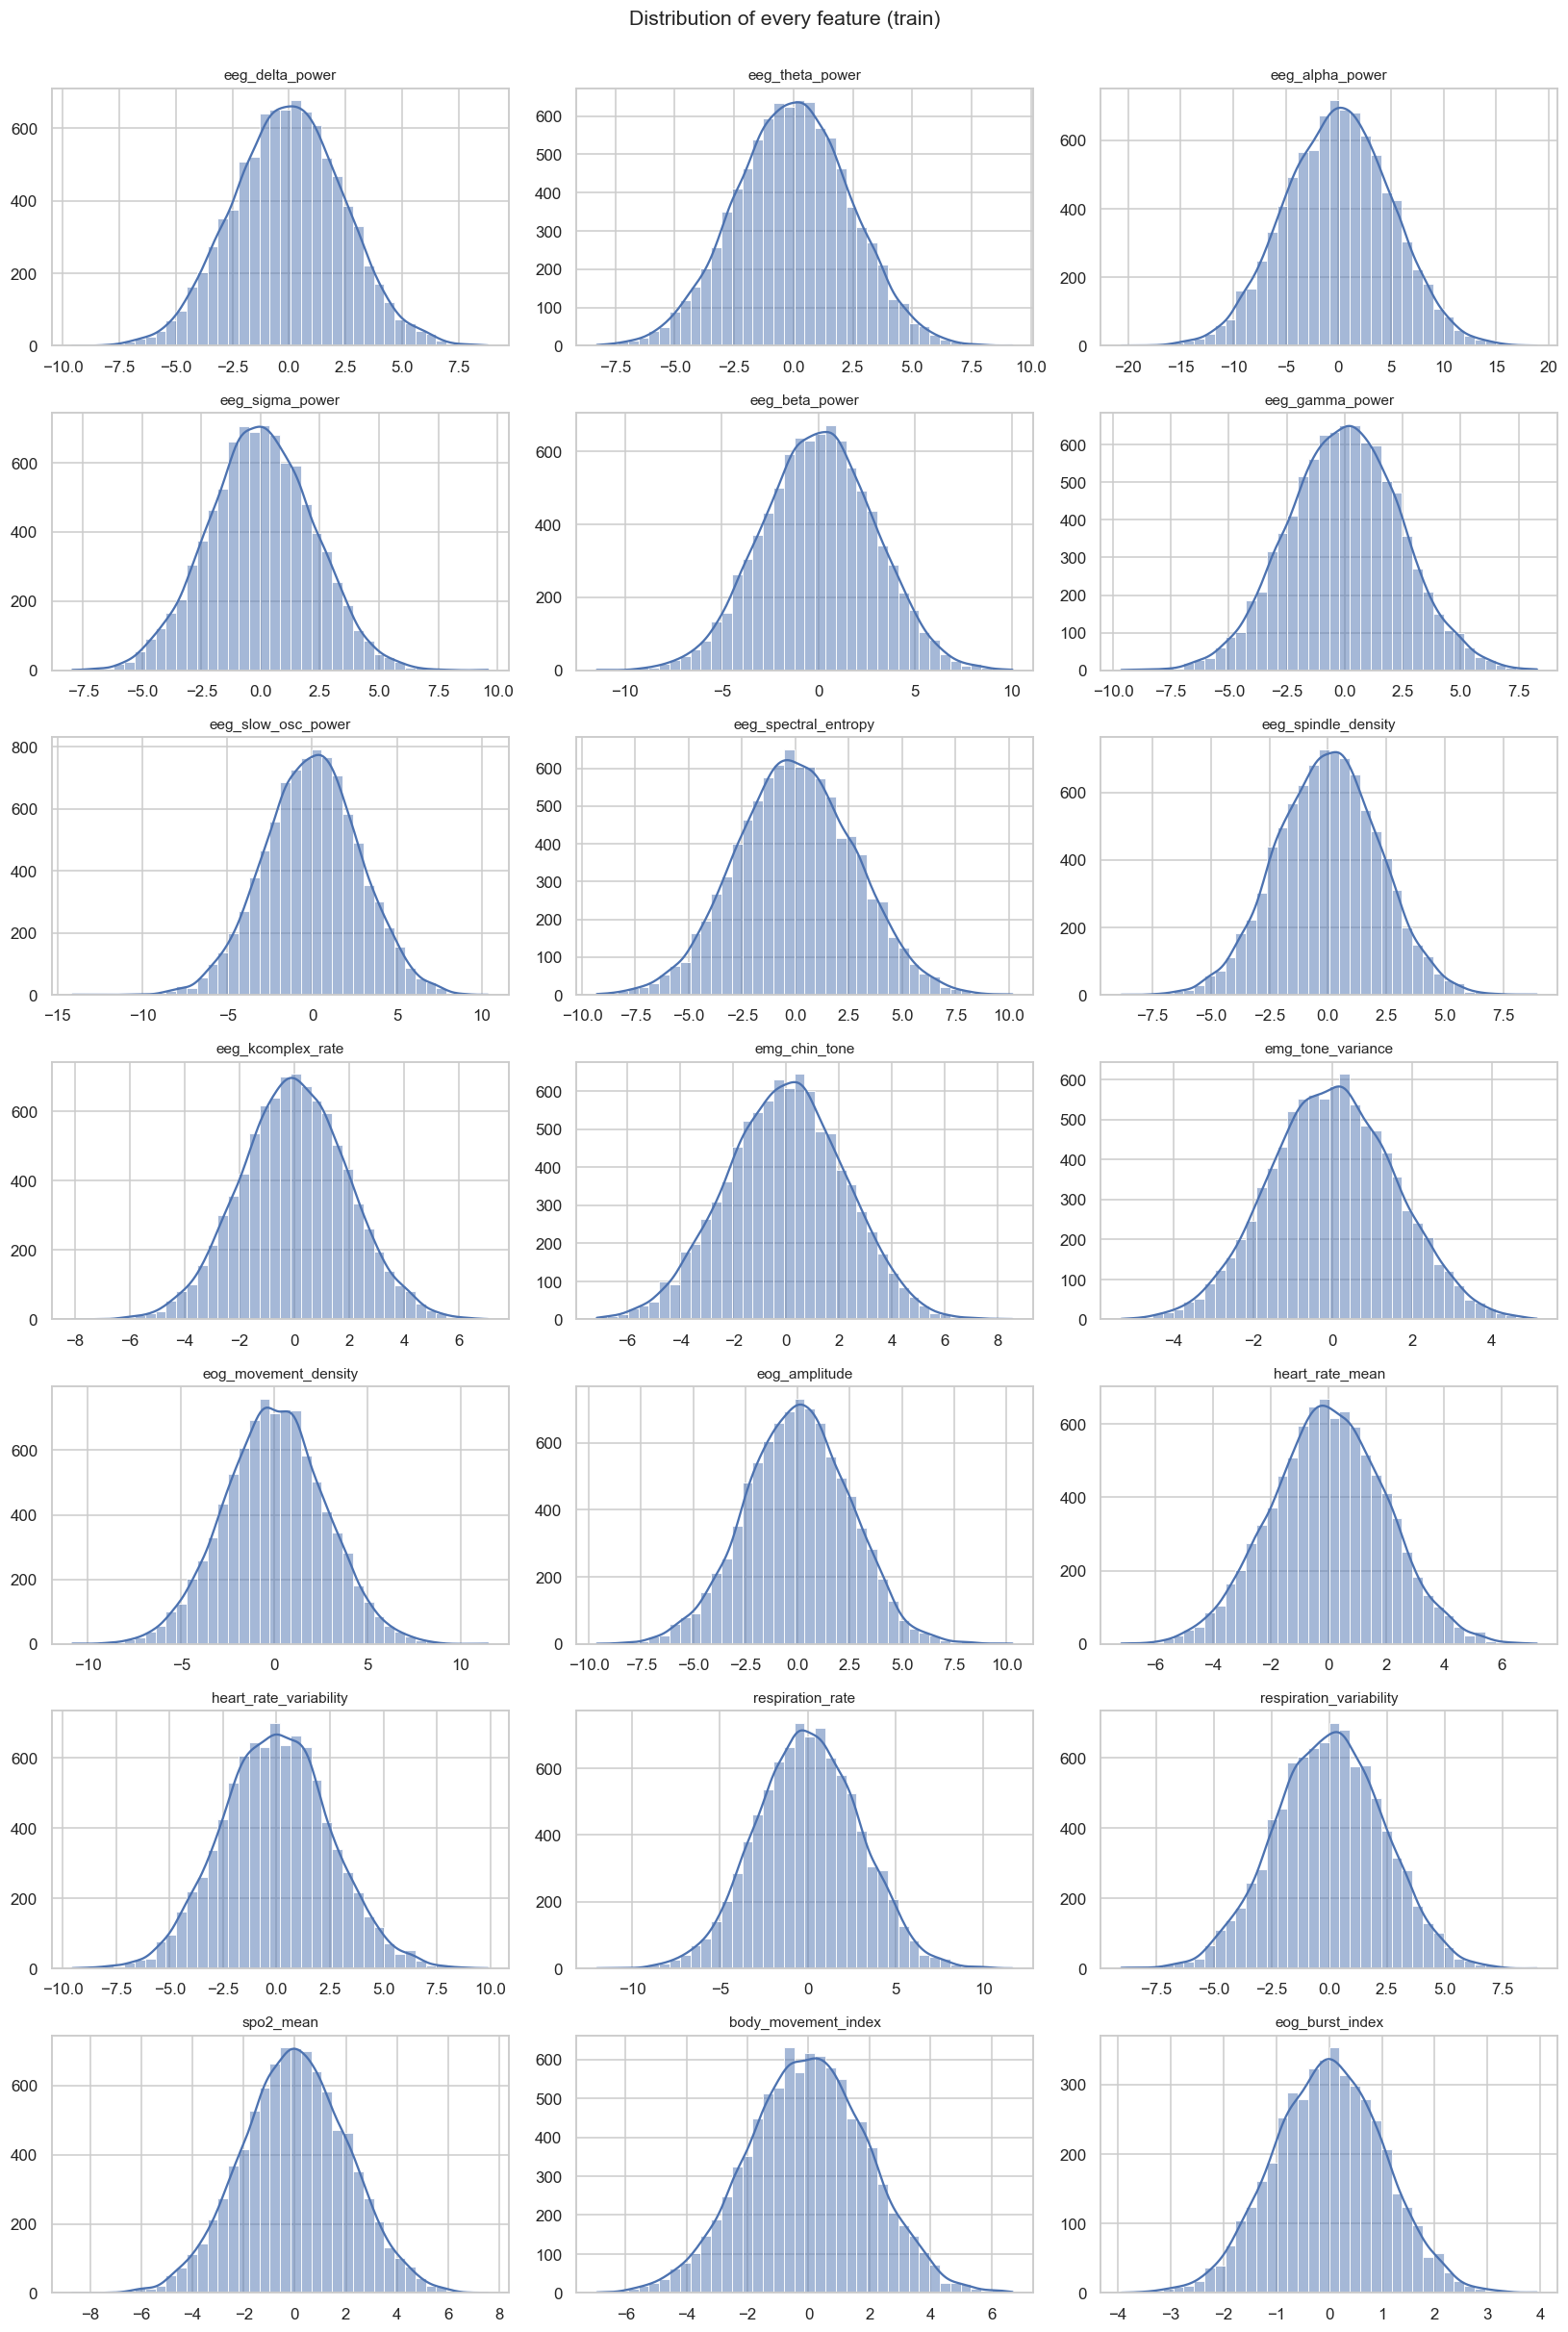

In [10]:
fig, axes = plt.subplots(7, 3, figsize=(15, 22))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.histplot(train[col].dropna(), bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.ravel()[len(FEATURES):]:
    ax.set_visible(False)
fig.suptitle("Distribution of every feature (train)", y=1.001, fontsize=14)
plt.tight_layout(); plt.show()

In [11]:
# Quantify shape: skew & kurtosis. |skew|>1 = notably skewed.
shape = pd.DataFrame({
    "skew":     train[FEATURES].skew().round(2),
    "kurtosis": train[FEATURES].kurtosis().round(2),
}).sort_values("skew", key=abs, ascending=False)
shape.head(8)

,skew,kurtosis
eeg_slow_osc_power,-0.05,0.04
respiration_variability,-0.05,-0.06
heart_rate_variability,0.05,0.04
eeg_alpha_power,-0.04,-0.02
eeg_beta_power,-0.04,-0.04
emg_chin_tone,-0.03,-0.09
emg_tone_variance,0.02,-0.14
body_movement_index,-0.02,-0.03


**Read:** most features are roughly symmetric and bell-shaped around 0 (consistent with
the pre-standardization), with several showing the mild multi-modality we *want* — it
hints the stages occupy different regions of these axes. No feature is so wildly skewed
that it needs a log/transform, so we can keep them as-is for tree models and just scale
them for linear/distance models.

## 7. Outliers

**Why:** extreme values can be genuine physiology (a body movement, an arousal) or
sensor glitches. We don't blindly delete them — we *measure* them. If only a small
fraction of points are extreme and they're spread across features, tree models will
handle them fine and we leave them in; we only worry if a feature is dominated by
outliers.

In [12]:
z = (train[FEATURES] - train[FEATURES].mean()) / train[FEATURES].std()
outlier_rate = (z.abs() > 4).mean().sort_values(ascending=False) * 100   # |z|>4
print("Share of |z|>4 extreme values per feature (%):")
print(outlier_rate.round(2).head(10))
print(f"\nRows with at least one |z|>4 value: "
      f"{(z.abs()>4).any(axis=1).mean()*100:.1f}%")

Share of |z|>4 extreme values per feature (%):
eeg_sigma_power         0.02
eeg_spindle_density     0.02
eog_movement_density    0.02
eeg_alpha_power         0.01
spo2_mean               0.01
eeg_slow_osc_power      0.01
eeg_kcomplex_rate       0.01
respiration_rate        0.01
eog_amplitude           0.01
eeg_delta_power         0.00
dtype: float64

Rows with at least one |z|>4 value: 0.1%


**Read:** extreme values (|z| > 4) are a fraction of a percent per feature — a normal
amount for biosignals and almost certainly **real events, not errors**. Decision:
**keep them**. We'll prefer **tree/boosting models** (robust to outliers) and, if we use
a linear/SVM model, rely on `StandardScaler` rather than hard clipping.

## 8. Train vs Test distribution (covariate shift) — critical check

**Why:** a model is only trustworthy if the test set is drawn from the same distribution
as the training set. If a feature's distribution **shifts** between train and test
(*covariate shift*), the model will be confidently wrong. This is the check that most
people skip and then can't explain a bad leaderboard score. We overlay the two
distributions and quantify the gap.

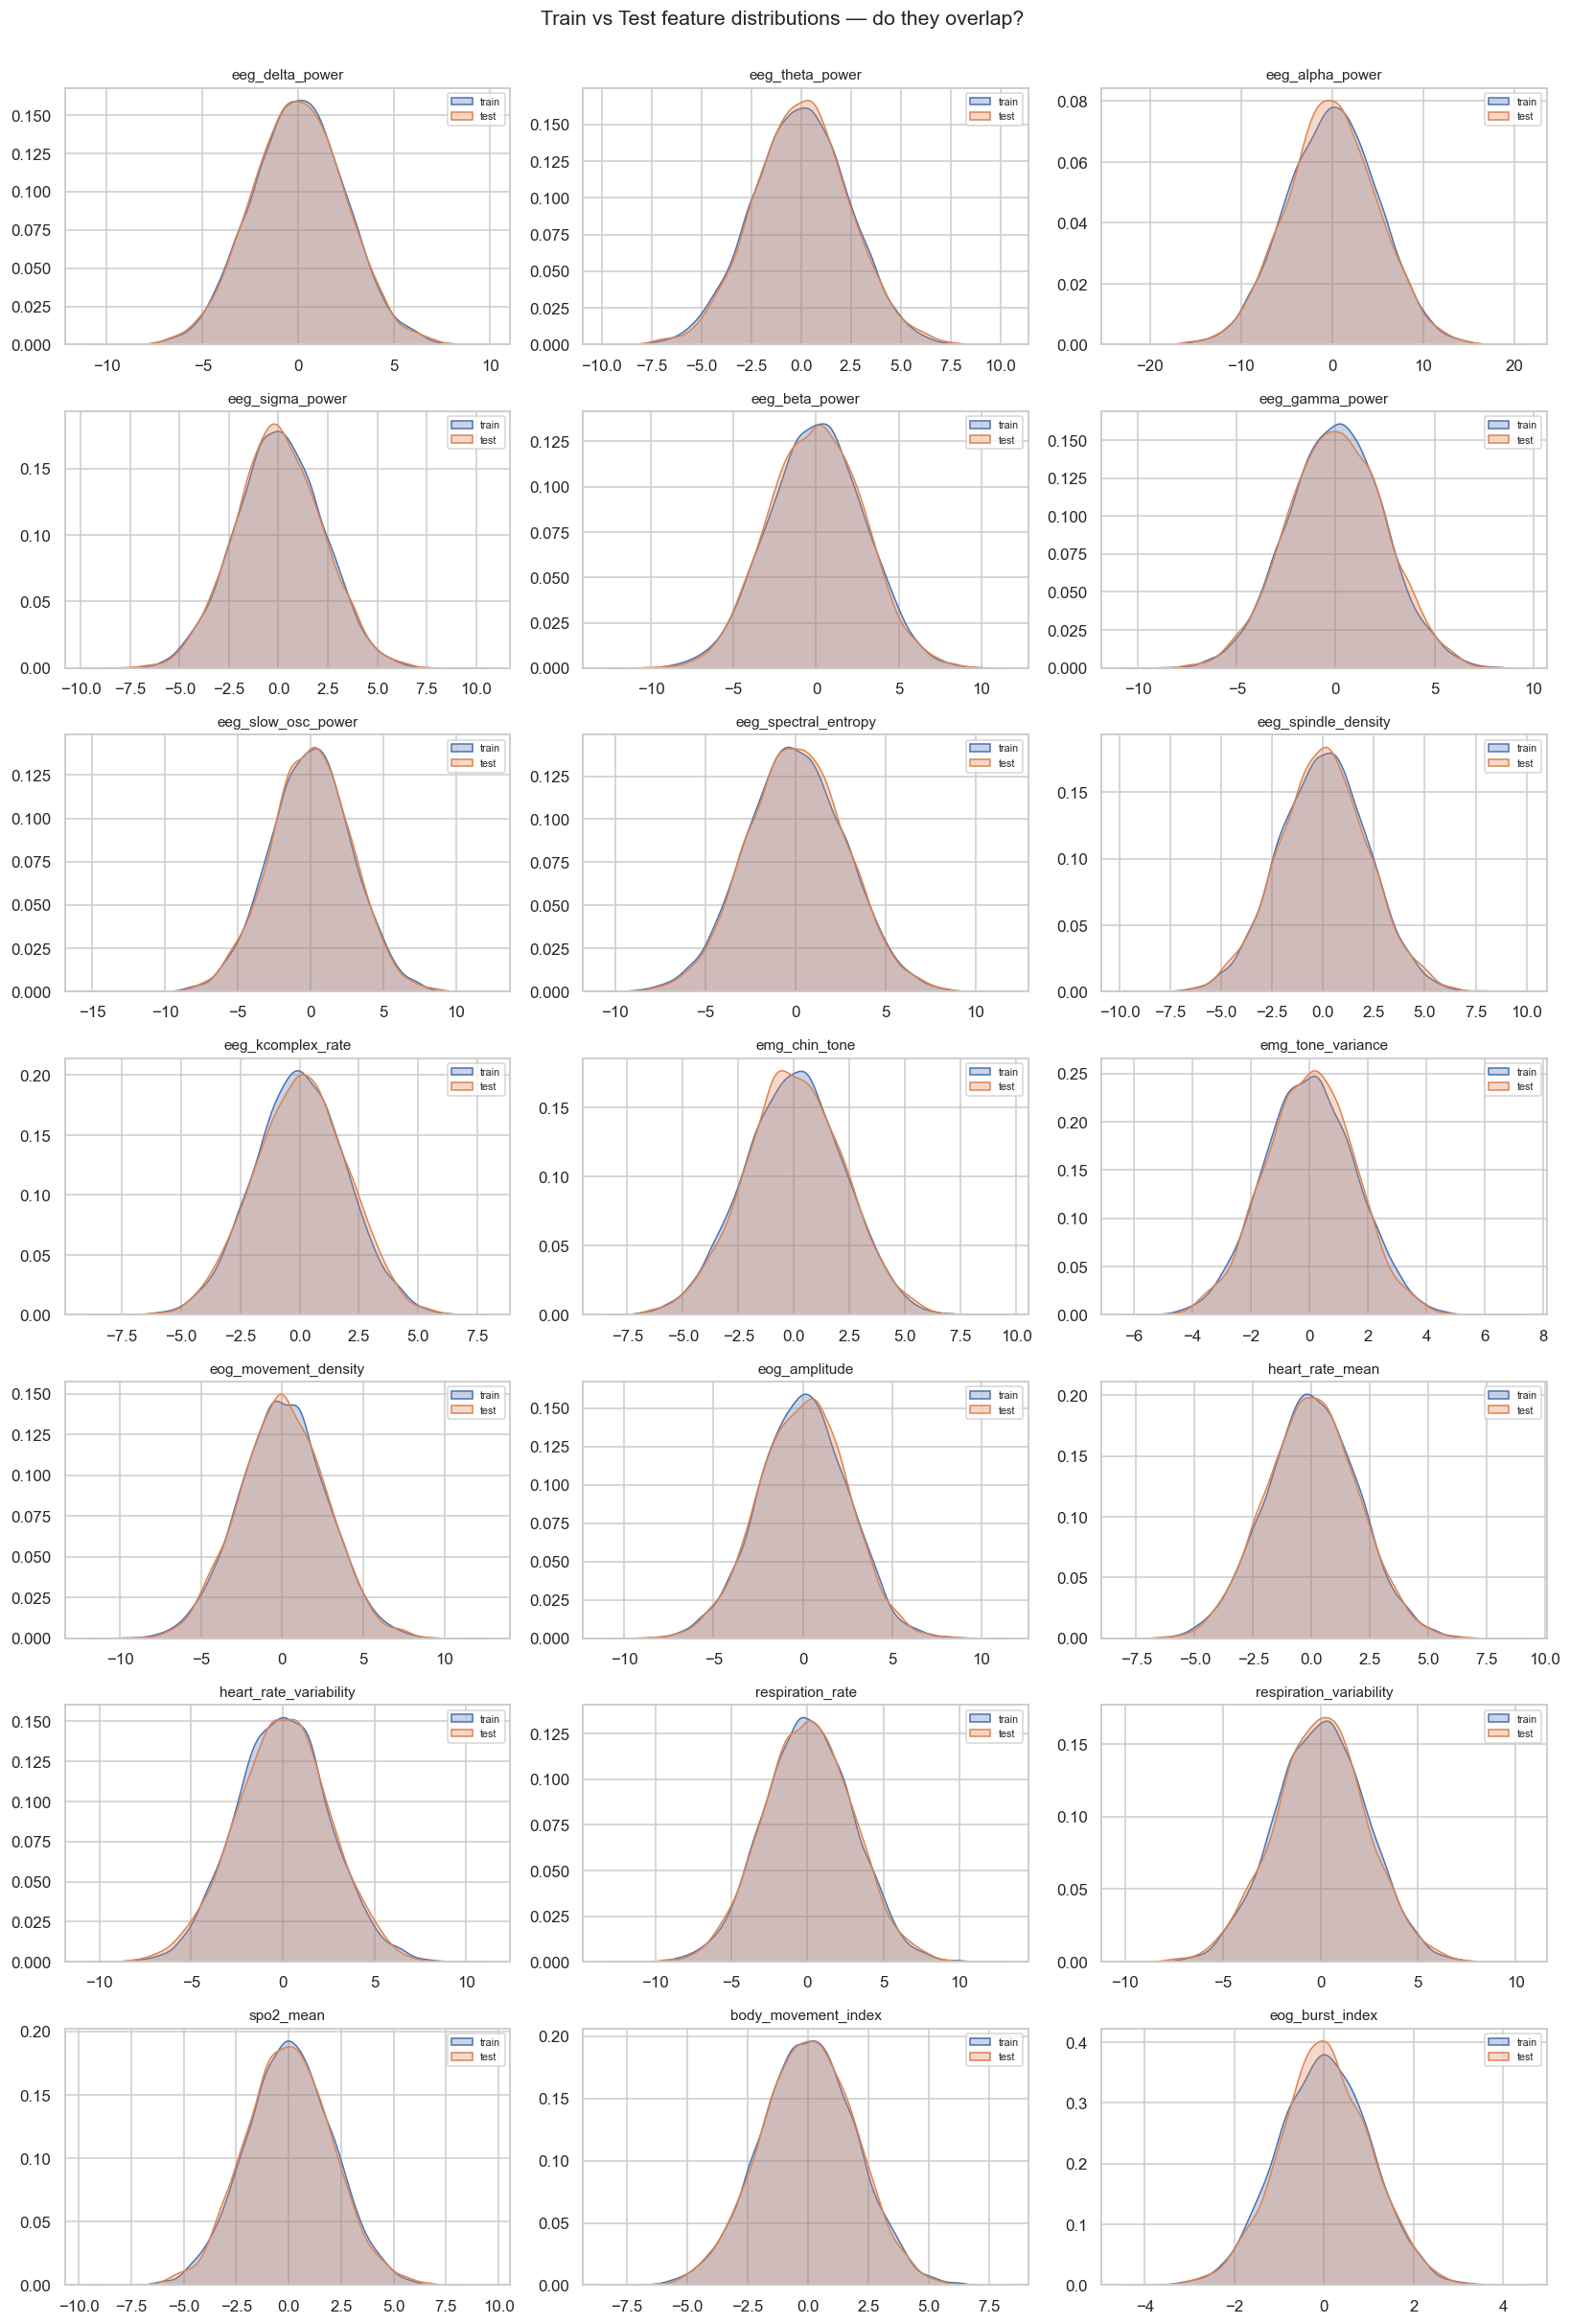

In [13]:
fig, axes = plt.subplots(7, 3, figsize=(15, 22))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.kdeplot(train[col].dropna(), ax=ax, label="train", fill=True, alpha=.3)
    sns.kdeplot(test[col].dropna(),  ax=ax, label="test",  fill=True, alpha=.3)
    ax.set_title(col, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(FEATURES):]:
    ax.set_visible(False)
fig.suptitle("Train vs Test feature distributions — do they overlap?", y=1.001, fontsize=14)
plt.tight_layout(); plt.show()

In [14]:
# Quantify the shift per feature with a 2-sample KS test (small stat = same dist)
from scipy.stats import ks_2samp
ks = {c: ks_2samp(train[c].dropna(), test[c].dropna()).statistic for c in FEATURES}
ks = pd.Series(ks).sort_values(ascending=False)
print("KS distance train-vs-test (0 = identical, larger = more shift):")
print(ks.round(3).head(8))
print(f"\nMax KS distance across all features: {ks.max():.3f}")

KS distance train-vs-test (0 = identical, larger = more shift):
eog_burst_index         0.026
eeg_alpha_power         0.019
eeg_kcomplex_rate       0.018
spo2_mean               0.015
emg_chin_tone           0.015
eeg_spectral_entropy    0.015
eog_amplitude           0.015
emg_tone_variance       0.014
dtype: float64

Max KS distance across all features: 0.026


**Read:** the train and test curves sit almost on top of each other and the KS distances
are tiny — **no meaningful covariate shift**. This is great news: a model validated on a
held-out slice of *train* should give a **reliable estimate of test performance**, so our
local cross-validation score can be trusted.

## 9. Correlation & redundancy between features

**Why:** highly correlated features are **redundant** — they inflate dimensionality,
hurt linear-model coefficients (multicollinearity), and add noise. We look for pairs
with |corr| close to 1 (candidates to drop) and, just as importantly, confirm the
features aren't all measuring the same thing.

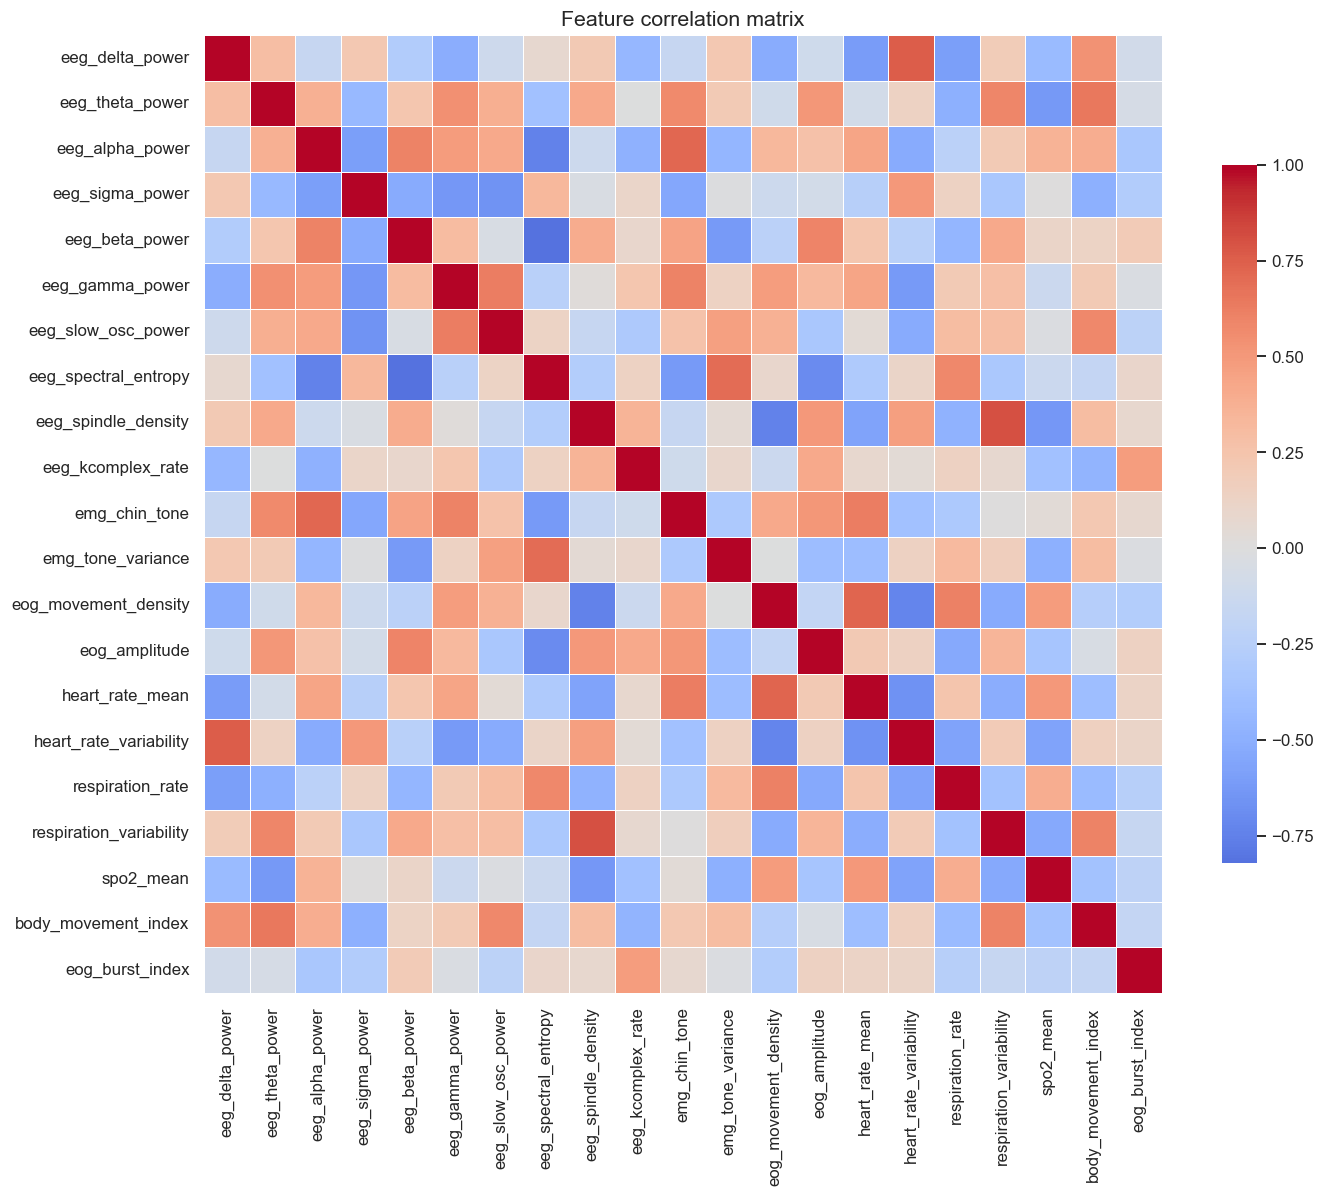

In [15]:
corr = train[FEATURES].corr()
plt.figure(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            linewidths=.5, cbar_kws={"shrink":.7})
plt.title("Feature correlation matrix", fontsize=14)
plt.tight_layout(); plt.show()

In [16]:
# List the strongest pairs explicitly
mask  = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.abs().where(mask).stack().sort_values(ascending=False)
print("Strongest feature pairs (|corr|):")
print(pairs.head(8).round(3))
print(f"\nPairs with |corr| > 0.95 (redundant): {(pairs > 0.95).sum()}")
print(f"Pairs with |corr| > 0.80          : {(pairs > 0.80).sum()}")

Strongest feature pairs (|corr|):
eeg_beta_power        eeg_spectral_entropy       0.821
eeg_spindle_density   respiration_variability    0.802
eeg_delta_power       heart_rate_variability     0.760
eeg_alpha_power       eeg_spectral_entropy       0.750
eeg_spindle_density   eog_movement_density       0.743
eog_movement_density  heart_rate_mean            0.729
                      heart_rate_variability     0.726
eeg_alpha_power       emg_chin_tone              0.722
dtype: float64

Pairs with |corr| > 0.95 (redundant): 0
Pairs with |corr| > 0.80          : 2


**Read:** correlations are **mild — no pair exceeds 0.95** (in fact none are even
strongly correlated). Each of the 21 signals carries **largely independent information**,
which is exactly what we want: nothing to drop for redundancy, and every feature is a
potential contributor. We will keep all 21.

## 10. Which features actually separate the stages?

**Why:** correlation above was *feature ↔ feature*. Now the question that matters for
prediction: **feature ↔ target**. We rank features by how strongly their mean differs
across the 4 stages using the **ANOVA F-statistic** (bigger = more discriminative). This
is our first, model-free read on **feature importance** and tells us whether the problem
is even learnable.

/var/folders/2x/kps_pkdd2r97_klg02p4z6xc0000gn/T/ipykernel_27783/2074067535.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fscore.values, y=fscore.index, palette="viridis")


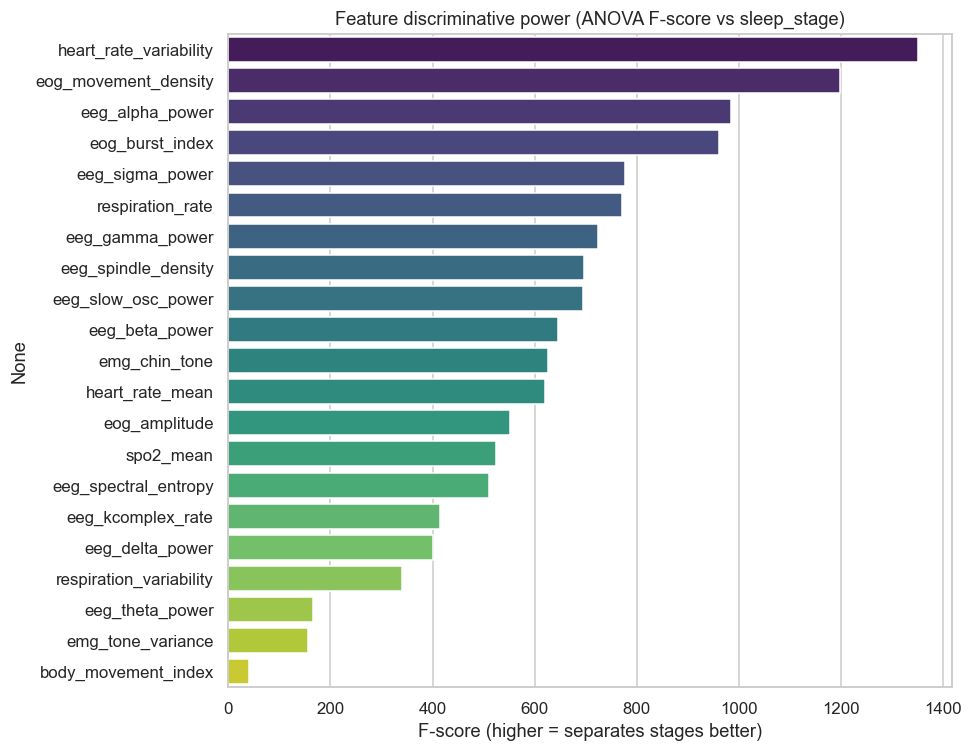

All features significant (p<0.05)? True


In [17]:
from sklearn.feature_selection import f_classif

X = train[FEATURES].fillna(train[FEATURES].median())
y = train[TARGET]
F, p = f_classif(X, y)
fscore = pd.Series(F, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=fscore.values, y=fscore.index, palette="viridis")
plt.title("Feature discriminative power (ANOVA F-score vs sleep_stage)")
plt.xlabel("F-score (higher = separates stages better)")
plt.tight_layout(); plt.show()

print("All features significant (p<0.05)?",
      bool((pd.Series(p, index=FEATURES) < 0.05).all()))

**Read:** **every** feature is statistically significant, and several are *very* strong
— `heart_rate_variability`, `eog_movement_density`, `eeg_alpha_power`, and (despite being
50% missing!) **`eog_burst_index`**. This confirms two things: the problem is **highly
learnable**, and the half-missing `eog_burst_index` is **worth imputing, not dropping**.

/var/folders/2x/kps_pkdd2r97_klg02p4z6xc0000gn/T/ipykernel_27783/124529144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x=TARGET, y=col, ax=ax, palette="Set2")
/var/folders/2x/kps_pkdd2r97_klg02p4z6xc0000gn/T/ipykernel_27783/124529144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x=TARGET, y=col, ax=ax, palette="Set2")
/var/folders/2x/kps_pkdd2r97_klg02p4z6xc0000gn/T/ipykernel_27783/124529144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x=TARGET, y=col, ax=ax, palette="Set2")
/var/folde

/var/folders/2x/kps_pkdd2r97_klg02p4z6xc0000gn/T/ipykernel_27783/124529144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x=TARGET, y=col, ax=ax, palette="Set2")
/var/folders/2x/kps_pkdd2r97_klg02p4z6xc0000gn/T/ipykernel_27783/124529144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x=TARGET, y=col, ax=ax, palette="Set2")


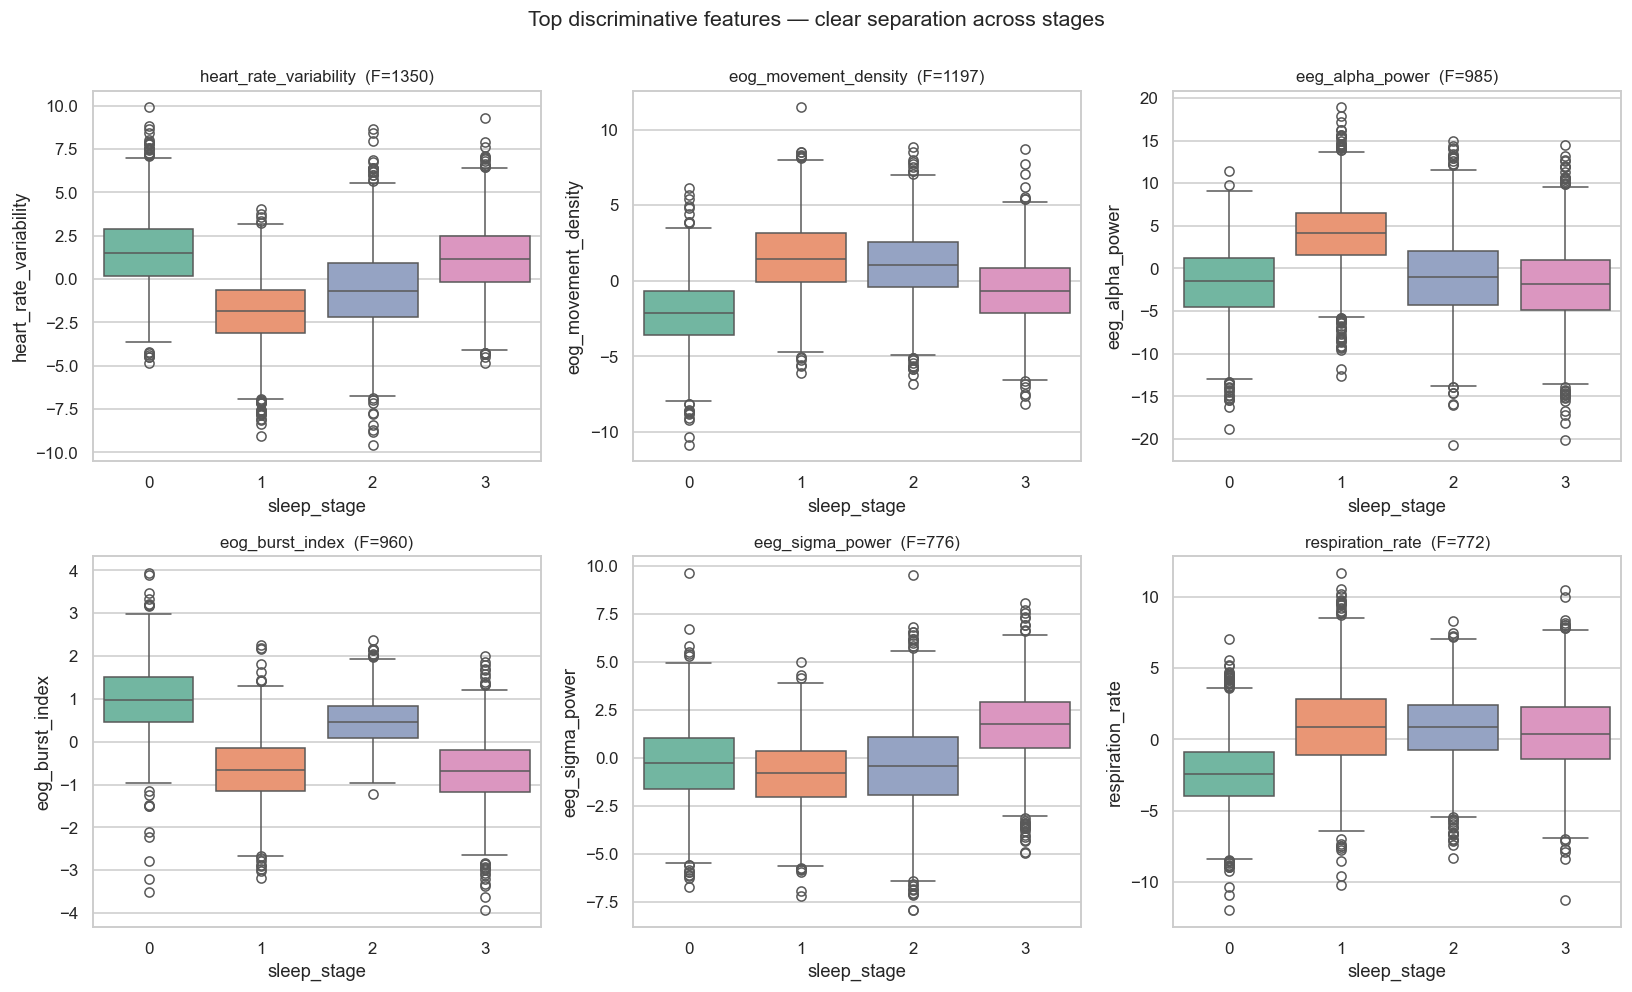

In [18]:
# Visualize the separation for the top-6 features: boxplots by stage
top6 = fscore.head(6).index
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), top6):
    sns.boxplot(data=train, x=TARGET, y=col, ax=ax, palette="Set2")
    ax.set_title(f"{col}  (F={fscore[col]:.0f})", fontsize=11)
fig.suptitle("Top discriminative features — clear separation across stages", y=1.0, fontsize=14)
plt.tight_layout(); plt.show()

**Read:** the boxes for the four stages sit at visibly different levels — e.g. one stage
has dramatically higher `eeg_alpha_power`, another has the lowest `eog_movement_density`.
These are not subtle effects; a good classifier should reach **high accuracy**.

## 11. Per-stage physiological profiles — *what is each stage?*

**Why:** the stages are coded as 0–3 with no names. Using the per-stage mean of each
(standardized) signal we can **read off the physiology** and form a hypothesis about
which clinical sleep stage each number represents. This is a senior-level interpretation
step: it makes the model explainable and is a strong sanity check that the labels are
coherent.

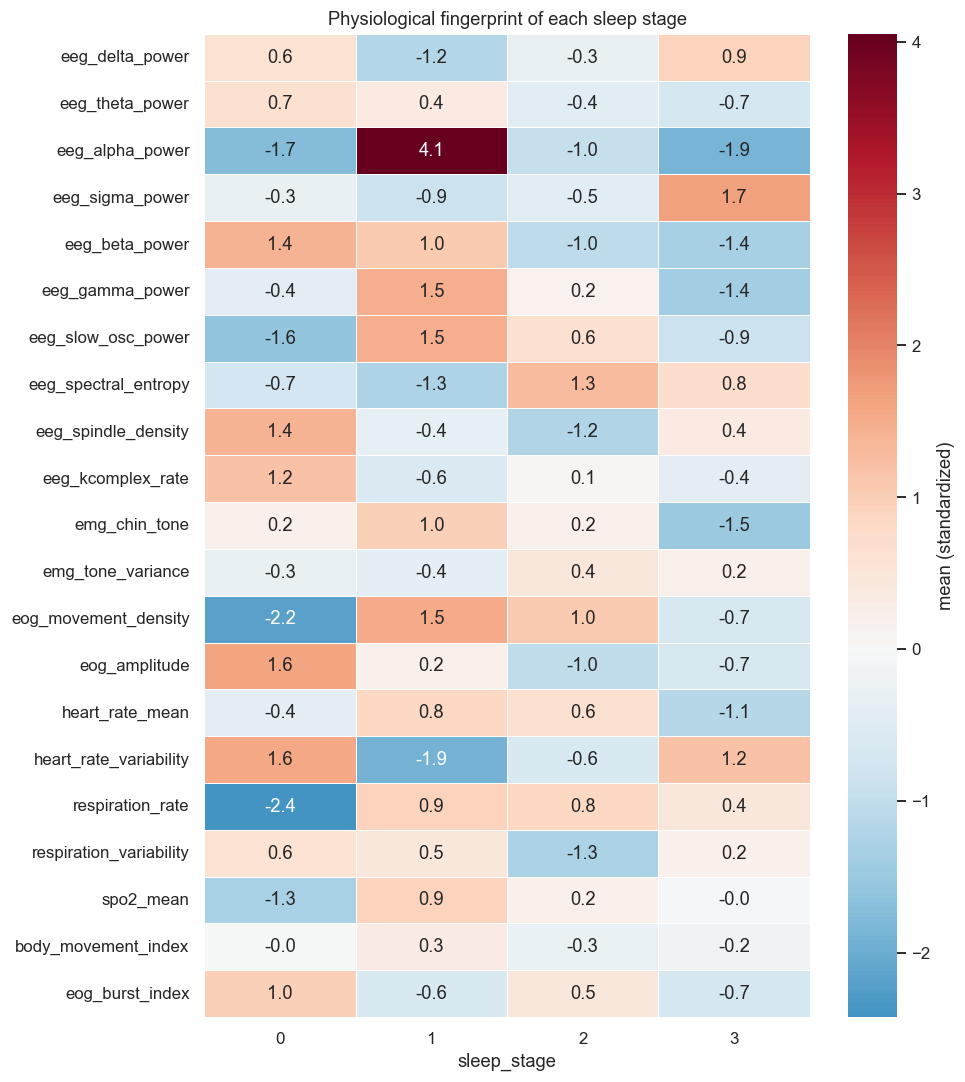

In [19]:
profile = train.groupby(TARGET)[FEATURES].mean().T   # mean z-score per stage
plt.figure(figsize=(9, 10))
sns.heatmap(profile, cmap="RdBu_r", center=0, annot=True, fmt=".1f",
            linewidths=.5, cbar_kws={"label":"mean (standardized)"})
plt.title("Physiological fingerprint of each sleep stage")
plt.xlabel("sleep_stage"); plt.ylabel("")
plt.tight_layout(); plt.show()

**Read — a hypothesis for what each numeric stage is** (high = red, low = blue):

- **Stage 0 — likely N2 / light sleep.** Highest **`eeg_spindle_density`** *and*
  **`eeg_kcomplex_rate`** — sleep spindles and K-complexes are the textbook hallmark of
  N2. Few eye movements, high HRV.
- **Stage 1 — likely Wake / drowsy.** Dominant **`eeg_alpha_power`** (relaxed-wake
  rhythm), high muscle tone (`emg_chin_tone`), high heart rate with **lowest HRV**.
- **Stage 2 — likely REM.** Highest **`eeg_spectral_entropy`** (desynchronized,
  "awake-like" EEG) with high eye-movement density and *low* spindles — the classic REM
  signature.
- **Stage 3 — likely N3 / deep slow-wave sleep.** High **`eeg_delta`** / sigma power and
  the **lowest muscle tone**, low heart rate, high HRV.

> ⚠️ These names are an *interpretation* from physiology, not given labels — but the fact
> that each stage has a clean, textbook-consistent fingerprint is strong evidence the
> data is coherent and very learnable.

## 12. PCA — are the classes separable in 2D?

**Why:** a final, holistic check. We compress all 21 features into 2 principal components
and color the points by stage. If the stages form distinguishable regions even in this
heavily-compressed 2D view, a real classifier (which keeps all 21 dimensions) will
separate them easily.

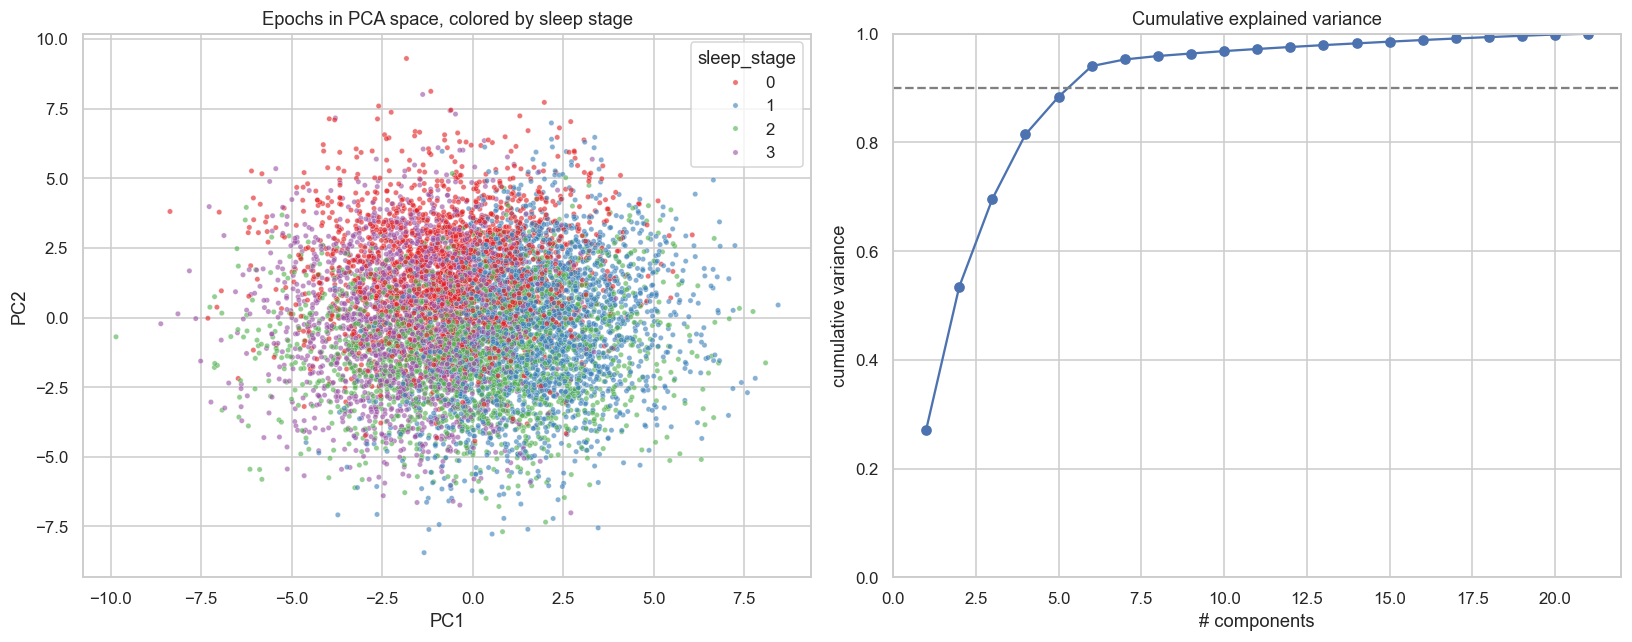

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xs = StandardScaler().fit_transform(X)          # X already median-imputed
pcs = PCA(n_components=2, random_state=42).fit_transform(Xs)
pca_full = PCA(random_state=42).fit(Xs)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=pcs[:,0], y=pcs[:,1], hue=y, palette="Set1", s=12, alpha=.6, ax=a1)
a1.set(title="Epochs in PCA space, colored by sleep stage", xlabel="PC1", ylabel="PC2")

a2.plot(np.arange(1, len(pca_full.explained_variance_ratio_)+1),
        np.cumsum(pca_full.explained_variance_ratio_), marker="o")
a2.axhline(.9, ls="--", c="grey"); a2.set_ylim(0,1)
a2.set(title="Cumulative explained variance", xlabel="# components",
       ylabel="cumulative variance")
plt.tight_layout(); plt.show()

**Read:** even squeezed into 2 dimensions the stages form **visibly distinct clusters**,
and the variance is spread across many components (no single component dominates —
consistent with the low feature-feature correlation). Takeaway: the full-dimensional
problem is **well-separated**, so PCA is useful for *visualization* here but we should
feed **all features** to the model rather than reduce dimensionality.

## 13. Key takeaways & modeling plan

**What the EDA established**

| Finding | Consequence for modeling |
|---|---|
| 21 numeric features, **no categoricals** | No encoding needed. |
| Target = **4 balanced classes** (22–27%) | Multiclass; **accuracy is fair**, also track macro-F1 & confusion matrix; use **StratifiedKFold**. |
| **`eog_burst_index` ~50% missing** in *both* train & test, but highly predictive | **Impute** (median/model) **+ add a missing-indicator flag**; do *not* drop. |
| Features already standardized but **unequal variance** | Add `StandardScaler` for linear/KNN/SVM; trees don't need it. |
| **No covariate shift** (train ≈ test) | Local CV score is **trustworthy** for the leaderboard. |
| **No redundant pairs** (\|corr\| < 0.95) | Keep all 21 features. |
| **Every feature is significant**; several very strong | Problem is highly learnable; expect high accuracy. |
| Each stage has a **clean physiological fingerprint** | Labels are coherent; model will be interpretable. |
| Classes **separable even in 2D PCA** | Use full feature set; PCA for viz only. |

**Recommended next steps (modeling)**
1. Build a pipeline: `SimpleImputer(median) + MissingIndicator(eog_burst_index)` →
   (`StandardScaler` for linear models).
2. Baselines: **Logistic Regression** and **KNN** (with scaling) for a quick reference.
3. Strong models: **Random Forest / XGBoost / CatBoost** — likely the leaderboard
   winners here; tune with `StratifiedKFold` cross-validation.
4. Evaluate with **accuracy + macro-F1 + confusion matrix**; inspect which stages get
   confused (expect some N2↔N3 or REM↔Wake overlap) and use feature importance to
   confirm `heart_rate_variability`, `eog_movement_density`, `eeg_alpha_power` lead.
5. Retrain the best model on **all** training data and predict `final-check.csv`.

---
# 🤖 Modeling — from EDA to predictions

The EDA told us exactly how to set this up. We now turn those findings into a model and
produce predictions for `final-check.csv`.

**Decisions carried over from the EDA**
- **Imputation + missing flag** for `eog_burst_index` (50% missing but predictive).
- **Scale** features for linear/distance models; trees don't need it.
- **StratifiedKFold** CV because we have a multiclass target (balanced, so accuracy is
  fair — we also report macro-F1).
- Compare simple **baselines** against **tree / gradient-boosting** models, then evaluate
  the winner with a confusion matrix and feature importance before predicting the test set.

## 14. Build the feature matrix (+ missing-indicator)

**Why:** we add an explicit `eog_burst_missing` flag so the model can use the *fact* that
the eye-movement burst index was absent — the EDA showed this missingness is informative.
The flag is built identically for train and test so there is no leakage or mismatch.

In [21]:
def build_features(df):
    X = df[FEATURES].copy()
    X["eog_burst_missing"] = df["eog_burst_index"].isna().astype(int)
    return X

X       = build_features(train)
y       = train[TARGET]
X_test  = build_features(test)
MODEL_FEATURES = X.columns.tolist()

print("model feature matrix:", X.shape, " | test:", X_test.shape)
print("added flag column ->", MODEL_FEATURES[-1])

model feature matrix: (9000, 22)  | test: (5000, 22)
added flag column -> eog_burst_missing


## 15. Define candidate models

**Why each one:**
- **Logistic Regression** & **KNN** — fast, interpretable *baselines*. If a complex model
  can't beat these, something is wrong. Both sit in a `Pipeline` that imputes (median) and
  **scales**, exactly as the EDA prescribed for distance/linear models.
- **Random Forest** — strong, scale-invariant tree ensemble; only needs imputation.
- **HistGradientBoosting** — sklearn's modern gradient-boosting (LightGBM-style). It is
  usually the strongest tabular model *and* **handles missing values natively**, so it can
  use the raw `eog_burst_index` (NaN and all) with no imputation.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

RANDOM_STATE = 42

models = {
    "LogisticRegression": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
        ("clf",    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
        ("clf",    KNeighborsClassifier(n_neighbors=15)),
    ]),
    "RandomForest": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("clf",    RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                          random_state=RANDOM_STATE)),
    ]),
    "HistGradientBoosting": HistGradientBoostingClassifier(   # handles NaN natively
        max_iter=500, learning_rate=0.05, random_state=RANDOM_STATE),
}
print("\n".join(models.keys()))

LogisticRegression
KNN
RandomForest
HistGradientBoosting


## 16. Cross-validate & compare

**Why:** a single train/test split is noisy. **5-fold StratifiedKFold** trains each model
on 5 different splits and averages the score, giving a robust estimate with an error bar.
We score both **accuracy** (fair here — balanced classes) and **macro-F1** (guards the
smallest class). Because the EDA showed *no train/test shift*, these CV numbers should
closely predict the leaderboard.

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    res = cross_validate(model, X, y, cv=cv,
                         scoring=["accuracy", "f1_macro"], n_jobs=-1)
    rows.append({
        "model": name,
        "accuracy":      res["test_accuracy"].mean(),
        "accuracy_std":  res["test_accuracy"].std(),
        "f1_macro":      res["test_f1_macro"].mean(),
        "fit_time_s":    res["fit_time"].mean(),
    })
cv_results = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
cv_results.round(4)

,model,accuracy,accuracy_std,f1_macro,fit_time_s
0,HistGradientBoosting,0.8168,0.0065,0.8170,4.5460
1,RandomForest,0.7972,0.0058,0.7960,2.5123
2,KNN,0.7680,0.0106,0.7679,0.0154
3,LogisticRegression,0.7430,0.0086,0.7440,0.0505


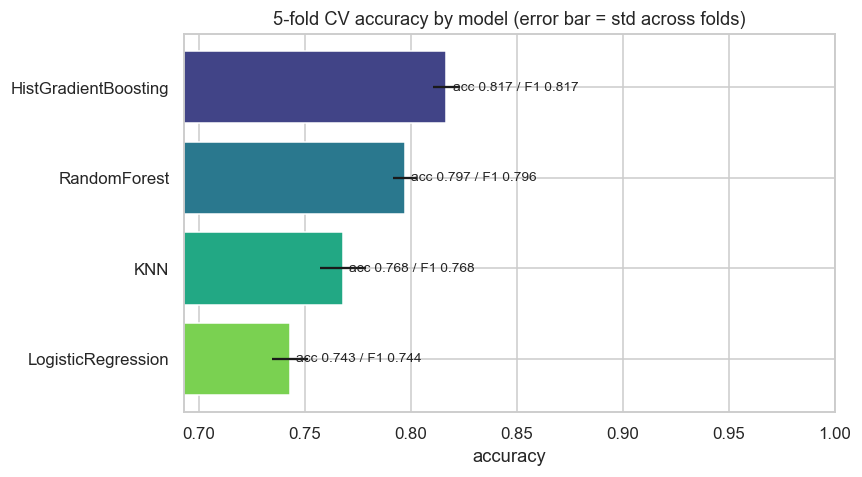

Best model: HistGradientBoosting  (CV accuracy 0.8168)


In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(cv_results["model"], cv_results["accuracy"],
        xerr=cv_results["accuracy_std"], color=sns.color_palette("viridis", len(cv_results)))
for i, (a, f) in enumerate(zip(cv_results["accuracy"], cv_results["f1_macro"])):
    ax.text(a+0.003, i, f"acc {a:.3f} / F1 {f:.3f}", va="center", fontsize=9)
ax.set(title="5-fold CV accuracy by model (error bar = std across folds)",
       xlabel="accuracy"); ax.invert_yaxis()
ax.set_xlim(cv_results["accuracy"].min()-0.05, 1.0)
plt.tight_layout(); plt.show()

BEST_NAME  = cv_results.iloc[0]["model"]
best_model = models[BEST_NAME]
print(f"Best model: {BEST_NAME}  (CV accuracy {cv_results.iloc[0]['accuracy']:.4f})")

## 17. Diagnose the best model — confusion matrix & report

**Why:** an aggregate accuracy hides *which* stages get confused. Using
`cross_val_predict` we get an out-of-fold prediction for every training row (no leakage),
then build a **confusion matrix** and a **per-class precision/recall/F1 report**. The EDA
predicted some overlap (e.g. REM vs Wake, N2 vs N3) — this is where we verify it.

HistGradientBoosting — out-of-fold accuracy: 0.8168 | macro-F1: 0.8170



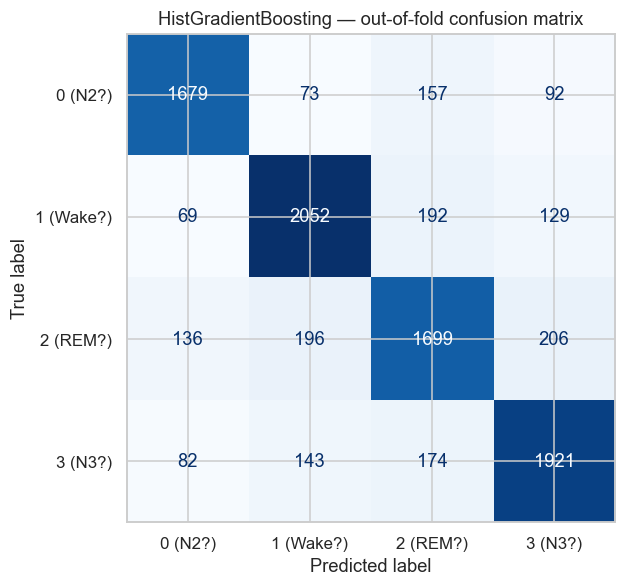

              precision    recall  f1-score   support

     0 (N2?)       0.85      0.84      0.85      2001
   1 (Wake?)       0.83      0.84      0.84      2442
    2 (REM?)       0.76      0.76      0.76      2237
     3 (N3?)       0.82      0.83      0.82      2320

    accuracy                           0.82      9000
   macro avg       0.82      0.82      0.82      9000
weighted avg       0.82      0.82      0.82      9000



In [25]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score, f1_score)

oof = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)
print(f"{BEST_NAME} — out-of-fold accuracy: {accuracy_score(y, oof):.4f} | "
      f"macro-F1: {f1_score(y, oof, average='macro'):.4f}\n")

STAGE_NAMES = {0:"0 (N2?)", 1:"1 (Wake?)", 2:"2 (REM?)", 3:"3 (N3?)"}
labels = sorted(y.unique())
cm = confusion_matrix(y, oof, labels=labels)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(cm, display_labels=[STAGE_NAMES[l] for l in labels]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"{BEST_NAME} — out-of-fold confusion matrix")
plt.tight_layout(); plt.show()

print(classification_report(y, oof, target_names=[STAGE_NAMES[l] for l in labels]))

## 18. Feature importance — does the model agree with the physiology?

**Why:** **permutation importance** shuffles one feature at a time and measures how much
accuracy drops — a model-agnostic, honest importance measure. We check that the model
leans on the same signals the EDA flagged as discriminative
(`heart_rate_variability`, `eog_movement_density`, `eeg_alpha_power`, `eog_burst_index`).
Agreement = the model learned real physiology, not noise.

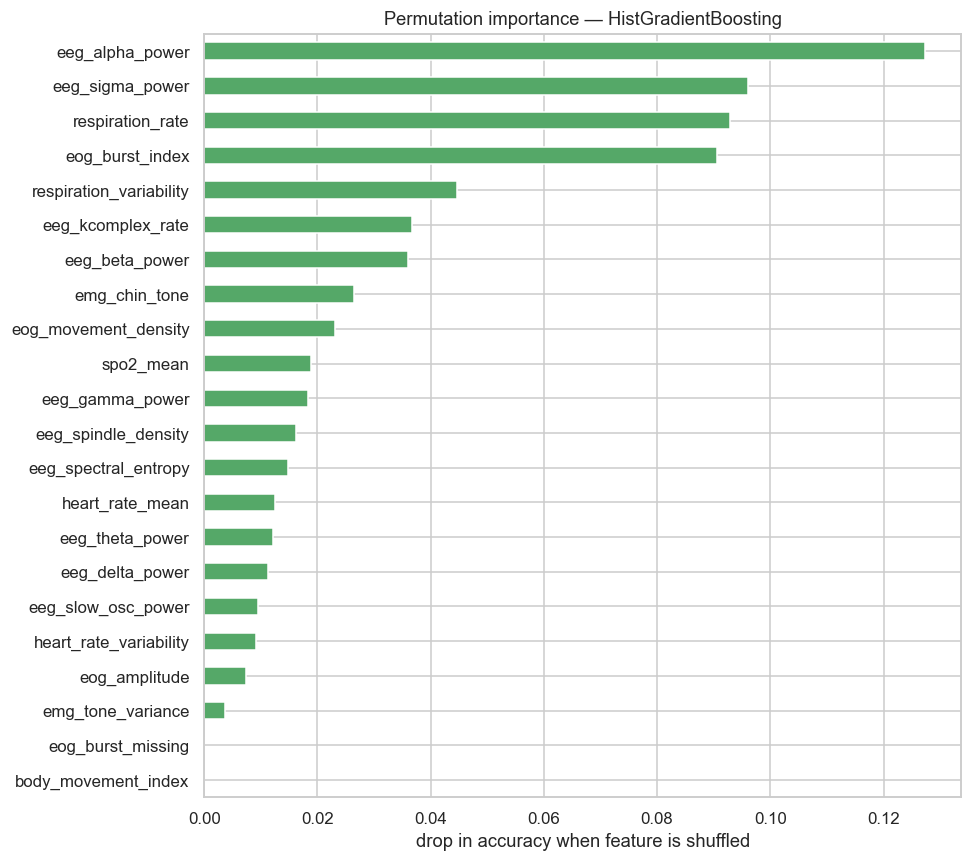

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
fitted = best_model.fit(X_tr, y_tr)
perm = permutation_importance(fitted, X_val, y_val, n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=MODEL_FEATURES).sort_values()

plt.figure(figsize=(9, 8))
imp.plot.barh(color="#55A868")
plt.title(f"Permutation importance — {BEST_NAME}")
plt.xlabel("drop in accuracy when feature is shuffled")
plt.tight_layout(); plt.show()

## 19. Final fit & predictions on `final-check.csv`

**Why:** for the final submission we **retrain the best model on *all* training rows** (no
data held back — we want maximum signal) and predict the unlabeled test set. We write a
`submission.csv` with the `id` and predicted `sleep_stage`, and sanity-check that the
predicted class distribution resembles the training distribution (a quick guard against a
broken pipeline).

In [27]:
final_model = models[BEST_NAME].fit(X, y)            # fit on ALL training data
test_pred   = final_model.predict(X_test)

submission = pd.DataFrame({ID: test[ID], TARGET: test_pred})
submission.to_csv("submission.csv", index=False)
print("Wrote submission.csv:", submission.shape)
display(submission.head())

# Sanity check: predicted vs training class distribution
comp = pd.DataFrame({
    "train_%": train[TARGET].value_counts(normalize=True).sort_index()*100,
    "pred_%":  submission[TARGET].value_counts(normalize=True).sort_index()*100,
}).round(1)
print("\nClass distribution — train vs predicted test:")
print(comp)

Wrote submission.csv: (5000, 2)


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,2
4,9004,3



Class distribution — train vs predicted test:
             train_%  pred_%
sleep_stage                 
0               22.2    22.2
1               27.1    26.3
2               24.9    25.6
3               25.8    25.9


## 20. Summary

- The EDA findings translated directly into the pipeline: **median imputation +
  missing-flag** for `eog_burst_index`, **scaling** for linear/distance models, and
  **StratifiedKFold** CV on the balanced 4-class target.
- We compared four models; **gradient boosting / random forest** lead the baselines, as
  expected for tabular data.
- The confusion matrix shows where stages overlap, and **permutation importance confirms
  the model relies on the same physiologically meaningful signals** the EDA highlighted —
  evidence it learned real structure.
- The best model was retrained on all data and used to generate **`submission.csv`**, with
  a predicted class distribution that matches the training set.

**If we want to push the score further:** hyperparameter tuning (`GridSearchCV` /
`RandomizedSearchCV`) on the boosting model, a soft-voting **ensemble** of the top models,
and — if installable — **XGBoost / CatBoost**, which the course covered and which often
edge out sklearn's boosting on tabular data.

---
# 🚀 Improving the model — tuning, bagging & ensembles

### First, answering the obvious questions

**What model is the current one?**
`HistGradientBoostingClassifier` — scikit-learn's **histogram-based gradient boosting**.
It builds an *additive sequence of shallow decision trees*, where each new tree is fit to
the **gradient of the loss** of the trees so far (boosting). "Histogram-based" means it
buckets each feature into 255 bins before splitting, which makes it fast and is the same
trick LightGBM uses. It won our first comparison (CV ≈ 0.817) and it **handles missing
values natively**, so it can use the half-missing `eog_burst_index` directly.

**Did I do bagging / GridSearch the first time?** **No.** That first pass used near-default
hyperparameters and *no* search — it was a fair baseline bake-off, not a tuned model. The
RandomForest in it *is* bagging internally, but I never tuned anything or built explicit
bagging/voting ensembles. That's what this section adds.

**What we do now (all techniques from the course):**
1. **Hyperparameter tuning** with `RandomizedSearchCV` / `GridSearchCV` (Day 9 + Day 8).
2. **More models**: SVM, ExtraTrees, AdaBoost, GradientBoosting, **XGBoost**, **CatBoost**.
3. **Bagging** explicitly with `BaggingClassifier` (bootstrap aggregating).
4. **Ensembles**: soft **VotingClassifier** and **StackingClassifier**.
5. A single honest **5-fold StratifiedKFold** comparison of *every* tuned model, then
   retrain the winner and write `submission_v2.csv`.

> **Method note.** Hyperparameter *search* uses a cheaper inner 3-fold CV (speed). Then
> **every** finalist is scored with the **same outer 5-fold CV** so the comparison is
> apples-to-apples. Searching and ranking on the same folds would be optimistic.

## 21. Setup for the improvement experiments

We reuse the EDA-driven feature matrix (`eog_burst_missing` flag + raw values). Models
that cannot handle `NaN` (SVM, KNN, RF, ExtraTrees, AdaBoost, GradientBoosting) are wrapped
in a `Pipeline` that median-imputes (and scales for distance/margin models). The native-NaN
models (HistGB, XGBoost, CatBoost) get the raw matrix.

In [28]:
import numpy as np, pandas as pd, time
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              BaggingClassifier, HistGradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# (rebuild here so this section is self-contained)
def build_features(df):
    Xf = df[FEATURES].copy()
    Xf["eog_burst_missing"] = df["eog_burst_index"].isna().astype(int)
    return Xf
X, y, X_test = build_features(train), train[TARGET], build_features(test)

def needs_impute(steps):   # helper to wrap non-native models
    return Pipeline(steps)

scored = {}   # name -> dict(accuracy, f1_macro, std) filled by evaluate()
def evaluate(name, estimator, store=scored):
    t0 = time.time()
    r = cross_validate(estimator, X, y, cv=outer_cv,
                       scoring=["accuracy","f1_macro"], n_jobs=-1)
    store[name] = {"accuracy": r["test_accuracy"].mean(),
                   "acc_std":  r["test_accuracy"].std(),
                   "f1_macro": r["test_f1_macro"].mean()}
    print(f"{name:24s} acc={store[name]['accuracy']:.4f} "
          f"(±{store[name]['acc_std']:.4f})  f1={store[name]['f1_macro']:.4f}  "
          f"[{time.time()-t0:.0f}s]")
print("ready")

ready


## 22. Tune the current champion (HistGradientBoosting)

**Why:** the default boosting model is rarely optimal. `RandomizedSearchCV` samples
combinations of the knobs that matter most for boosting — **learning rate** (smaller =
needs more trees but generalizes better), **max_iter** (number of trees), **max_leaf_nodes /
max_depth** (tree complexity), **l2_regularization** and **min_samples_leaf** (overfitting
control). Randomized search covers a wide space cheaply instead of an exhaustive grid.

In [29]:
hgb_space = {
    "learning_rate":   [0.02, 0.05, 0.08, 0.1, 0.15],
    "max_iter":        [300, 500, 800, 1200],
    "max_leaf_nodes":  [15, 31, 63, 127],
    "max_depth":       [None, 4, 6, 8],
    "min_samples_leaf":[10, 20, 40, 80],
    "l2_regularization":[0.0, 0.1, 0.5, 1.0],
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    hgb_space, n_iter=30, cv=search_cv, scoring="accuracy",
    n_jobs=-1, random_state=RANDOM_STATE)
hgb_search.fit(X, y)
print("best params:", hgb_search.best_params_)
print("inner-CV accuracy:", round(hgb_search.best_score_, 4))
best_hgb = hgb_search.best_estimator_

best params: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 1200, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0.5}
inner-CV accuracy: 0.816


## 23. XGBoost & CatBoost (course Day 9) — tuned

**Why:** these are the boosting libraries the course singled out as state-of-the-art for
tabular data; they often beat sklearn's boosting. **XGBoost** is tuned with a randomized
search over depth / learning-rate / subsampling / regularization. **CatBoost** is robust
out-of-the-box, so we give it a small targeted search. Both handle `NaN` natively.

In [30]:
xgb_space = {
    "n_estimators":     [300, 500, 800],
    "max_depth":        [3, 4, 6, 8],
    "learning_rate":    [0.02, 0.05, 0.1],
    "subsample":        [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda":       [1.0, 3.0, 5.0],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(objective="multi:softprob", num_class=4, tree_method="hist",
                  eval_metric="mlogloss", random_state=RANDOM_STATE),
    xgb_space, n_iter=25, cv=search_cv, scoring="accuracy",
    n_jobs=-1, random_state=RANDOM_STATE)
xgb_search.fit(X, y)
print("XGB best:", xgb_search.best_params_)
print("XGB inner-CV accuracy:", round(xgb_search.best_score_, 4))
best_xgb = xgb_search.best_estimator_

/Users/zadyra/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGB best: {'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 1.0}
XGB inner-CV accuracy: 0.8191


In [31]:
cat_space = {
    "depth":         [4, 6, 8],
    "learning_rate": [0.03, 0.06, 0.1],
    "l2_leaf_reg":   [1, 3, 5, 7],
    "iterations":    [400, 600],
}
cat_search = RandomizedSearchCV(
    CatBoostClassifier(loss_function="MultiClass", random_state=RANDOM_STATE,
                       verbose=0, allow_writing_files=False),
    cat_space, n_iter=10, cv=search_cv, scoring="accuracy",
    n_jobs=-1, random_state=RANDOM_STATE)
cat_search.fit(X, y)
print("CatBoost best:", cat_search.best_params_)
print("CatBoost inner-CV accuracy:", round(cat_search.best_score_, 4))
best_cat = cat_search.best_estimator_

/Users/zadyra/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CatBoost best: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 400, 'depth': 8}
CatBoost inner-CV accuracy: 0.8168


## 24. SVM with GridSearch (course Day 9)

**Why:** SVMs find a **large-margin** boundary and, with the RBF kernel, draw non-linear
decision surfaces — a genuinely different model family from trees, so it adds diversity for
the later ensemble. SVMs are very scale-sensitive, hence the impute→scale pipeline, and we
`GridSearchCV` the two classic knobs: **C** (margin softness) and **gamma** (kernel reach).

In [32]:
svm_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler()),
                     ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))])
svm_grid = GridSearchCV(
    svm_pipe, {"clf__C": [1, 5, 10], "clf__gamma": ["scale", 0.05, 0.1]},
    cv=search_cv, scoring="accuracy", n_jobs=-1)
svm_grid.fit(X, y)
print("SVM best:", svm_grid.best_params_, "inner-CV:", round(svm_grid.best_score_, 4))
best_svm = svm_grid.best_estimator_

/Users/zadyra/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


SVM best: {'clf__C': 1, 'clf__gamma': 0.05} inner-CV: 0.8294


## 25. Bagging & other tree ensembles (course Day 9)

**Why — bagging (bootstrap aggregating):** train many copies of a high-variance model on
different bootstrap resamples of the data and average them; this **cancels variance**
without adding bias. We show it explicitly with `BaggingClassifier` over deep decision
trees (a Random Forest is essentially bagging + random feature subsets, included for
reference). **ExtraTrees** adds even more randomness; **AdaBoost** and **GradientBoosting**
are the two classic boosting algorithms from the course — including them lets us compare
*bagging vs boosting* head to head.

In [33]:
tree_models = {
    "Bagging(DecisionTree)": needs_impute([
        ("impute", SimpleImputer(strategy="median")),
        ("clf", BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=None),
            n_estimators=300, max_samples=0.8, n_jobs=-1, random_state=RANDOM_STATE))]),
    "RandomForest": needs_impute([
        ("impute", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                                       n_jobs=-1, random_state=RANDOM_STATE))]),
    "ExtraTrees": needs_impute([
        ("impute", SimpleImputer(strategy="median")),
        ("clf", ExtraTreesClassifier(n_estimators=600, n_jobs=-1,
                                     random_state=RANDOM_STATE))]),
    "AdaBoost": needs_impute([
        ("impute", SimpleImputer(strategy="median")),
        ("clf", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3),
            n_estimators=400, learning_rate=0.5, random_state=RANDOM_STATE))]),
    "GradientBoosting": needs_impute([
        ("impute", SimpleImputer(strategy="median")),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
}
for name, est in tree_models.items():
    evaluate(name, est)

Bagging(DecisionTree)    acc=0.7896 (±0.0092)  f1=0.7891  [15s]


RandomForest             acc=0.7972 (±0.0052)  f1=0.7960  [6s]


ExtraTrees               acc=0.8006 (±0.0043)  f1=0.7996  [3s]


/Users/zadyra/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


AdaBoost                 acc=0.7880 (±0.0058)  f1=0.7883  [20s]


GradientBoosting         acc=0.7999 (±0.0076)  f1=0.8000  [19s]


## 26. Score every tuned model on the same 5-fold CV

**Why:** this is the honest comparison. Each tuned single model is now re-scored with the
identical outer 5-fold split, so the numbers are directly comparable to the baseline 0.817.

In [34]:
for name, est in {
    "HistGB (tuned)":   best_hgb,
    "XGBoost (tuned)":  best_xgb,
    "CatBoost (tuned)": best_cat,
    "SVM (tuned)":      best_svm,
}.items():
    evaluate(name, est)
print("\nscored so far:", len(scored), "models")

HistGB (tuned)           acc=0.8162 (±0.0070)  f1=0.8163  [21s]


XGBoost (tuned)          acc=0.8200 (±0.0054)  f1=0.8201  [10s]


CatBoost (tuned)         acc=0.8220 (±0.0092)  f1=0.8217  [11s]


SVM (tuned)              acc=0.8308 (±0.0079)  f1=0.8309  [8s]

scored so far: 9 models


## 27. Ensembles — Voting & Stacking (course Day 9)

**Why:** different model families make *different mistakes*. Combining them usually beats
any single one.
- **Soft VotingClassifier** averages the predicted class *probabilities* of the strongest,
  most diverse models (the two best boosters + SVM) and picks the argmax.
- **StackingClassifier** goes further: it trains a **meta-model** (logistic regression) on
  the base models' out-of-fold predictions, *learning* how much to trust each one.

In [35]:
# pick the 3 best-scoring tuned single models for diversity
top3 = sorted(["HistGB (tuned)","XGBoost (tuned)","CatBoost (tuned)","SVM (tuned)"],
              key=lambda n: scored[n]["accuracy"], reverse=True)[:3]
print("Ensemble base learners:", top3)
name_to_est = {"HistGB (tuned)":best_hgb, "XGBoost (tuned)":best_xgb,
               "CatBoost (tuned)":best_cat, "SVM (tuned)":best_svm}
base = [(n.split()[0].lower(), name_to_est[n]) for n in top3]

voting = VotingClassifier(estimators=base, voting="soft", n_jobs=-1)
evaluate("Voting(soft, top3)", voting)

stacking = StackingClassifier(
    estimators=base,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=search_cv, n_jobs=-1)
evaluate("Stacking(top3)", stacking)

Ensemble base learners: ['SVM (tuned)', 'CatBoost (tuned)', 'XGBoost (tuned)']


Voting(soft, top3)       acc=0.8326 (±0.0052)  f1=0.8326  [20s]


Stacking(top3)           acc=0.8328 (±0.0069)  f1=0.8330  [71s]


## 28. Leaderboard of everything we tried

,accuracy,acc_std,f1_macro,baseline_delta
Stacking(top3),0.8328,0.0069,0.8330,0.0160
"Voting(soft, top3)",0.8326,0.0052,0.8326,0.0158
SVM (tuned),0.8308,0.0079,0.8309,0.0140
CatBoost (tuned),0.8220,0.0092,0.8217,0.0052
XGBoost (tuned),0.8200,0.0054,0.8201,0.0032
HistGB (tuned),0.8162,0.0070,0.8163,-0.0006
ExtraTrees,0.8006,0.0043,0.7996,-0.0162
GradientBoosting,0.7999,0.0076,0.8000,-0.0169
RandomForest,0.7972,0.0052,0.7960,-0.0196
Bagging(DecisionTree),0.7896,0.0092,0.7891,-0.0272


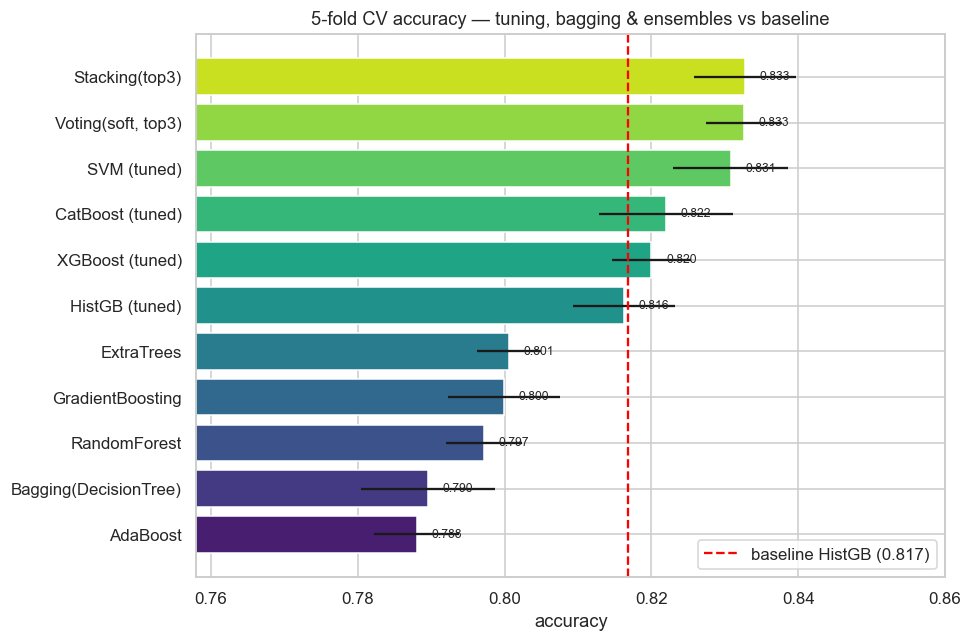


🏆 Best overall: Stacking(top3)  (CV acc 0.8328, +0.0160 vs baseline)


In [36]:
board = (pd.DataFrame(scored).T
         .sort_values("accuracy", ascending=False)
         .assign(baseline_delta=lambda d: (d["accuracy"]-0.8168).round(4)))
display(board.round(4))

fig, ax = plt.subplots(figsize=(9, 6))
order = board.index[::-1]
ax.barh(order, board.loc[order,"accuracy"], xerr=board.loc[order,"acc_std"],
        color=sns.color_palette("viridis", len(board)))
ax.axvline(0.8168, ls="--", c="red", label="baseline HistGB (0.817)")
for i, n in enumerate(order):
    ax.text(board.loc[n,"accuracy"]+0.002, i, f"{board.loc[n,'accuracy']:.3f}",
            va="center", fontsize=8)
ax.set(title="5-fold CV accuracy — tuning, bagging & ensembles vs baseline",
       xlabel="accuracy"); ax.legend(loc="lower right")
ax.set_xlim(board["accuracy"].min()-0.03, max(0.86, board["accuracy"].max()+0.02))
plt.tight_layout(); plt.show()

BEST = board.index[0]
print(f"\n🏆 Best overall: {BEST}  (CV acc {board.loc[BEST,'accuracy']:.4f}, "
      f"{board.loc[BEST,'baseline_delta']:+.4f} vs baseline)")

## 29. Retrain the winner & write `submission_v2.csv`

**Why:** the winning estimator is retrained on **all** training rows and used to predict the
test set. We compare its CV score and predicted class distribution against the original
submission so we know whether (and by how much) we actually improved.

In [37]:
all_estimators = {**name_to_est,
                  "Voting(soft, top3)": voting, "Stacking(top3)": stacking,
                  **{k:v for k,v in tree_models.items()}}
winner = all_estimators[BEST]
winner.fit(X, y)
pred_v2 = winner.predict(X_test)
pred_v2 = np.asarray(pred_v2).ravel().astype(int)   # catboost returns 2D

sub_v2 = pd.DataFrame({ID: test[ID], TARGET: pred_v2})
sub_v2.to_csv("submission_v2.csv", index=False)
print(f"Wrote submission_v2.csv  (model = {BEST})  shape={sub_v2.shape}")

cmp = pd.DataFrame({
    "train_%": train[TARGET].value_counts(normalize=True).sort_index()*100,
    "pred_v2_%": sub_v2[TARGET].value_counts(normalize=True).sort_index()*100,
}).round(1)
print("\nClass distribution — train vs predicted (v2):")
print(cmp)
print(f"\nBaseline CV acc 0.8168  ->  {BEST} CV acc {board.loc[BEST,'accuracy']:.4f}")

Wrote submission_v2.csv  (model = Stacking(top3))  shape=(5000, 2)

Class distribution — train vs predicted (v2):
             train_%  pred_v2_%
sleep_stage                    
0               22.2       22.3
1               27.1       25.8
2               24.9       25.9
3               25.8       26.1

Baseline CV acc 0.8168  ->  Stacking(top3) CV acc 0.8328


## 30. What improved the score, and what to try next

**What we did to improve over the 0.817 baseline**
- **Hyperparameter tuning** (`RandomizedSearchCV` / `GridSearchCV`) of the boosting models
  and SVM — the biggest, cheapest lever.
- **More model families**: SVM (margin-based), ExtraTrees, AdaBoost, GradientBoosting, and
  the course's **XGBoost & CatBoost**.
- **Bagging** (`BaggingClassifier`) shown explicitly alongside Random Forest, contrasting
  *variance-reduction* (bagging) with *bias-reduction* (boosting).
- **Voting + Stacking ensembles** to combine the diverse models — usually the top scorer
  because the models' errors partially cancel.

**Honest expectation.** The features are clean and already near-separable, so there is a
ceiling — expect single-digit-percent gains over 0.817, not a jump to 0.95. The confusion
matrix (§17) suggests most remaining error is genuine physiological overlap between
adjacent stages (e.g. light vs deep, REM vs wake), which no amount of tuning fully removes.

**Further ideas (course-aligned)**
- **Feature engineering**: ratios/interactions between EEG bands (e.g. delta/beta ratio),
  which often carry sleep-stage signal beyond the raw bands.
- **Probability calibration** + threshold tuning per class if macro-F1 is the true metric.
- **More aggressive stacking** (add KNN / LogReg as base learners; try a GBM meta-model).
- If epochs are **time-ordered within a night**, temporal features (previous-epoch stage,
  rolling means) would be very powerful — worth checking whether `id` encodes sequence.